### Residual Water결과정리 


LOADING: easy

LOADING: medium

LOADING: hard


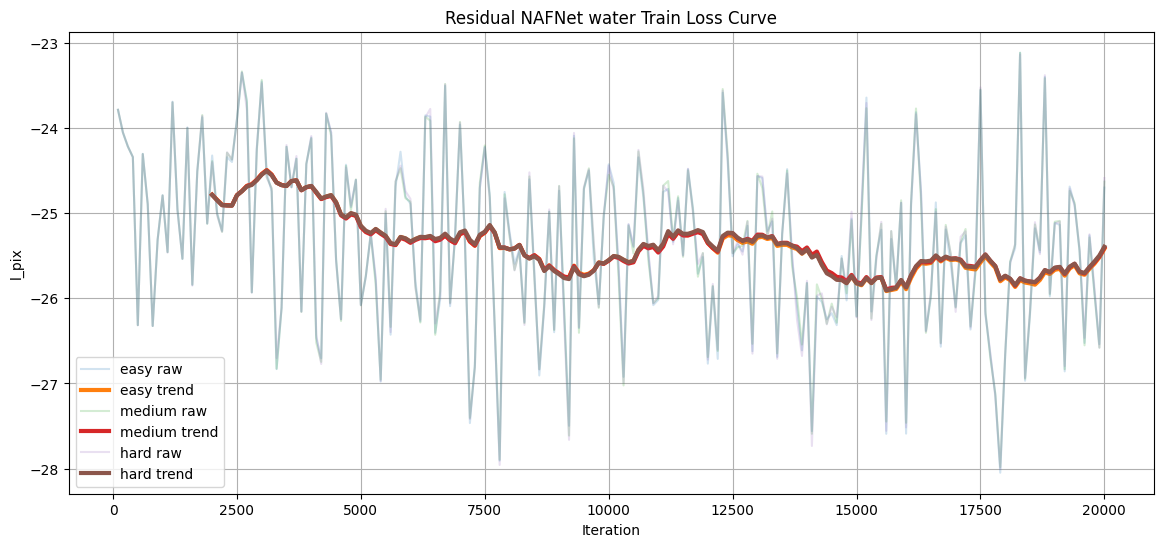

In [4]:
import re
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

log_dict = {

    'easy': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\Residual-NAFNet-water-easy-w16'
        r'\train_Residual-NAFNet-water-easy-w16_20260605_102444.log'
    ),

    'medium': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\Residual-NAFNet-water-medium-w16'
        r'\train_Residual-NAFNet-water-medium-w16_20260605_161813.log'
    ),

    'hard': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\Residual-NAFNet-water-hard-w16'
        r'\train_Residual-NAFNet-water-hard-w16_20260605_131723.log'
    )
}


# =========================================================
# REGEX
# =========================================================

train_pattern = re.compile(
    r'iter:\s*([\d,]+).*?l_pix:\s*(-?[0-9.eE+]+)'
)

val_pattern = re.compile(
    r'Validation.*?# psnr:\s*([0-9.]+)\s*# ssim:\s*([0-9.]+)'
)

iter_pattern = re.compile(
    r'iter:\s*([\d,]+)'
)

# =========================================================
# STORAGE
# =========================================================

results = {}

# =========================================================
# PARSE LOGS
# =========================================================

for difficulty, log_path in log_dict.items():

    print(f'\nLOADING: {difficulty}')

    with open(
        log_path,
        'r',
        encoding='utf-8'
    ) as f:

        lines = f.readlines()

    train_iters = []
    train_losses = []

    val_iters = []
    val_psnr = []
    val_ssim = []

    current_iter = None

    for line in lines:

        # -------------------------------------------------
        # CURRENT ITER
        # -------------------------------------------------

        iter_match = iter_pattern.search(line)

        if iter_match:

            current_iter = int(
                iter_match.group(1).replace(',', '')
            )

        # -------------------------------------------------
        # TRAIN LOSS
        # -------------------------------------------------

        train_match = train_pattern.search(line)

        if train_match:

            iteration = int(
                train_match.group(1).replace(',', '')
            )

            loss = float(
                train_match.group(2)
            )

            train_iters.append(iteration)
            train_losses.append(loss)

        # -------------------------------------------------
        # VALIDATION
        # -------------------------------------------------

        val_match = val_pattern.search(line)

        if val_match and current_iter is not None:

            psnr = float(
                val_match.group(1)
            )

            ssim = float(
                val_match.group(2)
            )

            val_iters.append(current_iter)
            val_psnr.append(psnr)
            val_ssim.append(ssim)

    results[difficulty] = {

        'train_iters': train_iters,
        'train_losses': train_losses,

        'val_iters': val_iters,
        'val_psnr': val_psnr,
        'val_ssim': val_ssim
    }

# =========================================================
# FIGURE 1 : TRAIN LOSS
# =========================================================

plt.figure(figsize=(14, 6))

window = 20

for difficulty in results:

    x = results[difficulty]['train_iters']
    y = results[difficulty]['train_losses']

    plt.plot(
        x,
        y,
        alpha=0.2,
        label=f'{difficulty} raw'
    )

    smooth = (
        pd.Series(y)
        .rolling(window)
        .mean()
    )

    plt.plot(
        x,
        smooth,
        linewidth=3,
        label=f'{difficulty} trend'
    )

plt.xlabel('Iteration')
plt.ylabel('l_pix')

plt.title(
    'Residual NAFNet water Train Loss Curve'
)

plt.legend()
plt.grid(True)

plt.show()

## mixed 실험결과 아키텍처 변경 후 


LOADING: easy

LOADING: medium

LOADING: hard


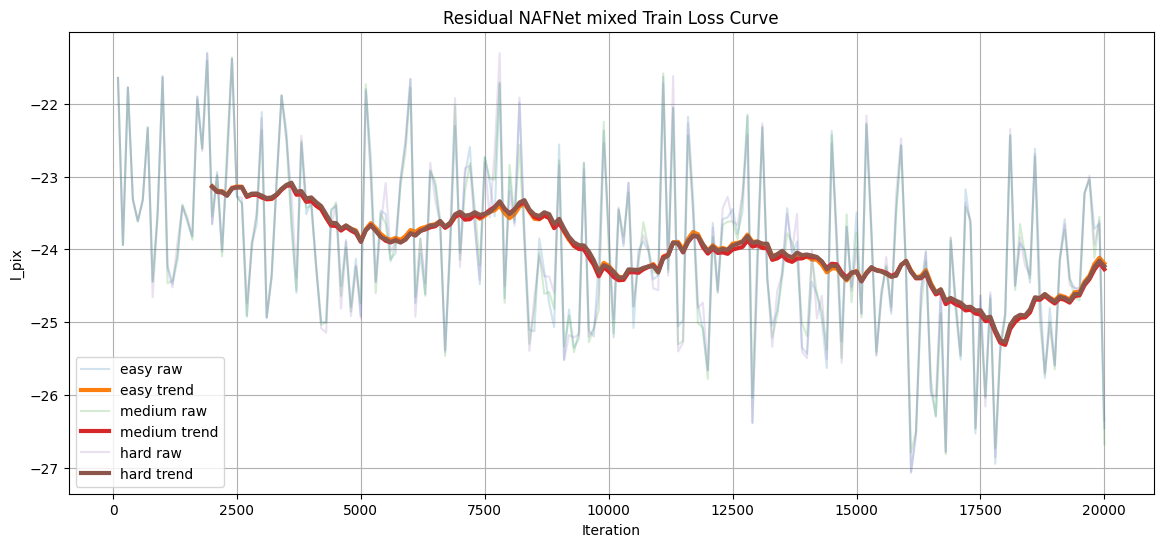

In [6]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

log_dict = {

    'easy': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\Residual-NAFNet-mixed-easy-w16'
        r'\train_Residual-NAFNet-mixed-easy-w16_20260605_013439.log'
    ),

    'medium': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\Residual-NAFNet-mixed-medium-w16'
        r'\train_Residual-NAFNet-mixed-medium-w16_20260605_073054.log'
    ),

    'hard': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\Residual-NAFNet-mixed-hard-w16'
        r'\train_Residual-NAFNet-mixed-hard-w16_20260605_043047.log'
    )
}


# =========================================================
# REGEX
# =========================================================

train_pattern = re.compile(
    r'iter:\s*([\d,]+).*?l_pix:\s*(-?[0-9.eE+]+)'
)

val_pattern = re.compile(
    r'Validation.*?# psnr:\s*([0-9.]+)\s*# ssim:\s*([0-9.]+)'
)

iter_pattern = re.compile(
    r'iter:\s*([\d,]+)'
)

# =========================================================
# STORAGE
# =========================================================

results = {}

# =========================================================
# PARSE LOGS
# =========================================================

for difficulty, log_path in log_dict.items():

    print(f'\nLOADING: {difficulty}')

    with open(
        log_path,
        'r',
        encoding='utf-8'
    ) as f:

        lines = f.readlines()

    train_iters = []
    train_losses = []

    val_iters = []
    val_psnr = []
    val_ssim = []

    current_iter = None

    for line in lines:

        # -------------------------------------------------
        # CURRENT ITER
        # -------------------------------------------------

        iter_match = iter_pattern.search(line)

        if iter_match:

            current_iter = int(
                iter_match.group(1).replace(',', '')
            )

        # -------------------------------------------------
        # TRAIN LOSS
        # -------------------------------------------------

        train_match = train_pattern.search(line)

        if train_match:

            iteration = int(
                train_match.group(1).replace(',', '')
            )

            loss = float(
                train_match.group(2)
            )

            train_iters.append(iteration)
            train_losses.append(loss)

        # -------------------------------------------------
        # VALIDATION
        # -------------------------------------------------

        val_match = val_pattern.search(line)

        if val_match and current_iter is not None:

            psnr = float(
                val_match.group(1)
            )

            ssim = float(
                val_match.group(2)
            )

            val_iters.append(current_iter)
            val_psnr.append(psnr)
            val_ssim.append(ssim)

    results[difficulty] = {

        'train_iters': train_iters,
        'train_losses': train_losses,

        'val_iters': val_iters,
        'val_psnr': val_psnr,
        'val_ssim': val_ssim
    }

# =========================================================
# FIGURE 1 : TRAIN LOSS
# =========================================================

plt.figure(figsize=(14, 6))

window = 20

for difficulty in results:

    x = results[difficulty]['train_iters']
    y = results[difficulty]['train_losses']

    plt.plot(
        x,
        y,
        alpha=0.2,
        label=f'{difficulty} raw'
    )

    smooth = (
        pd.Series(y)
        .rolling(window)
        .mean()
    )

    plt.plot(
        x,
        smooth,
        linewidth=3,
        label=f'{difficulty} trend'
    )

plt.xlabel('Iteration')
plt.ylabel('l_pix')

plt.title(
    'Residual NAFNet mixed Train Loss Curve'
)

plt.legend()
plt.grid(True)

plt.show()
